# 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from googleapiclient.discovery import build
from google.oauth2.service_account import Credentials
import re
from graphdatascience import GraphDataScience

# 1. Load Data

### Functions

In [2]:
def get_credentials(cred_file, scopes):
  cred = Credentials.from_service_account_file(cred_file, scopes=scopes)
  return cred

def build_sheet(cred):
  service = build('sheets', 'v4', credentials=cred)
  sheet = service.spreadsheets()
  return sheet

def read_sheets(sheet, sheet_id, range, columns=None):
  result = sheet.values().get(spreadsheetId=sheet_id, range=range).execute()
  rows = result.get('values', [])
  if columns is None and len(rows) >= 0:
    columns = rows[0]
  elif columns:
    columns = columns
  else:
    print('If sheet is empty, provide column names')
    return
  data = rows[1:] if len(rows) > 1 else []
  df = pd.DataFrame(data, columns=columns)
  return df

def write_to_sheets(sheet, sheet_id, range, values):
  data = {'values': values}
  sheet.values().update(
      spreadsheetId=sheet_id,
      range=range,
      valueInputOption="RAW",
      body=data
  ).execute()
  print('Data berhasil ditulis')

def delete_range(sheet, sheet_id, range):
  sheet.values().clear(
      spreadsheetId=sheet_id,
      range=range
  ).execute()

In [3]:
CRED_PATH = 'credentials/bw2024-96e33661eb9c.json'
SCOPES = ['https://www.googleapis.com/auth/spreadsheets']

credentials = get_credentials(cred_file=CRED_PATH, scopes=SCOPES)
sheet = build_sheet(cred=credentials)

### Sheet IDs

In [4]:
EXPERT_SHEET_ID = "1pfXu9wfwjgwGLrzelZobVBC7EzWb5qQKaZcieszv2dY"

STUDENT_7_SHEET_ID = "1esmk1W0mkAQb-D4M6efGv_Y3kJSi6aCTNDz1sYdx_iI"
STUDENT_5_SHEET_ID = "1WIhS28QmpzW0deYSEE9L9fgsptVn6mu3SqzKUxjmmIc"
STUDENT_2_SHEET_ID = "1xjsvZa1L8JJAyqTI-AsNbFvynDMjUq0lFbQNdyFJC68"
STUDENT_8_SHEET_ID = "1xnjTPvou-rNuL96zJ5YcAGyIttKXwyHUPCq8b5hp680"
STUDENT_1_SHEET_ID = "1YsS-IWHZgGCOhCnl7YE75Z526gTC9ACKvOxCcMMEj6w"
STUDENT_3_SHEET_ID = "1SzfV3X353N2m4tOmNfFHFVe60BnilmDw3t38d0yTc7w"
STUDENT_4_SHEET_ID = "1abMvy0ZA1gyoOvnES1jOiuQevOO4h3RSBfA9TVnTQQE"
STUDENT_6_SHEET_ID = "199G92FcC8xZ4Mrq7fPuf0zQ2FRMhShT8wPCowqvAVAI"
STUDENT_9_SHEET_ID = "1IZvqr4OT3CrHTAupxnhsmpsfszN6XystSlQdNtVpHIo"

STUDENTS_SHEET_ID = [STUDENT_1_SHEET_ID,
                     STUDENT_2_SHEET_ID,
                     STUDENT_3_SHEET_ID,
                     STUDENT_4_SHEET_ID,
                     STUDENT_5_SHEET_ID,
                     STUDENT_6_SHEET_ID,
                     STUDENT_7_SHEET_ID,
                     STUDENT_8_SHEET_ID,
                     STUDENT_9_SHEET_ID]

### Load & Normalize Data

In [5]:
expert_df = read_sheets(sheet=sheet, sheet_id=EXPERT_SHEET_ID, range="Form Responses 1")
expert_df.drop(columns=["Score"], inplace=True)
expert_df.drop(columns=["Email Address"], inplace=True)

student_1_df = read_sheets(sheet=sheet, sheet_id=STUDENT_1_SHEET_ID, range="Form Responses 1")
student_2_df = read_sheets(sheet=sheet, sheet_id=STUDENT_2_SHEET_ID, range="Form Responses 2")
student_3_df = read_sheets(sheet=sheet, sheet_id=STUDENT_3_SHEET_ID, range="Form Responses 2")
student_4_df = read_sheets(sheet=sheet, sheet_id=STUDENT_4_SHEET_ID, range="Form Responses 2")
student_5_df = read_sheets(sheet=sheet, sheet_id=STUDENT_5_SHEET_ID, range="Form Responses 2")
student_6_df = read_sheets(sheet=sheet, sheet_id=STUDENT_6_SHEET_ID, range="Form Responses 2")
student_7_df = read_sheets(sheet=sheet, sheet_id=STUDENT_7_SHEET_ID, range="Form Responses 2")
student_8_df = read_sheets(sheet=sheet, sheet_id=STUDENT_8_SHEET_ID, range="Form Responses 2")
student_9_df = read_sheets(sheet=sheet, sheet_id=STUDENT_9_SHEET_ID, range="Form Responses 2")

students_df = [student_1_df,
               student_2_df,
               student_3_df,
               student_4_df,
               student_5_df,
               student_6_df,
               student_7_df,
               student_8_df,
               student_9_df]

In [6]:
def normalize_survey_data(df):
    records = []
    for index, row in df.iterrows():
        timestamp = row.iloc[0]
        name = row.iloc[1]
        posisi = row.iloc[2]
        for student_idx in range(9):
            base_col_idx = 3 + (student_idx * 5)
            if base_col_idx + 4 >= len(df.columns):
                break   
            mahasiswa_ke = student_idx + 1
            komentar = row.iloc[base_col_idx + 4]
            for rank_idx in range(4):
                col_idx = base_col_idx + rank_idx
                col_name = df.columns[col_idx]
                relevansi = row.iloc[col_idx]
                if pd.isna(relevansi):
                    continue
                match = re.search(r'\((.*?)\)', col_name)
                kegiatan = match.group(1) if match else "Unknown"
                
                ranking = rank_idx + 1
                records.append({
                    "timestamp": timestamp,
                    "name": name,
                    "position": posisi,
                    "n-th student": mahasiswa_ke,
                    "recommended event": kegiatan,
                    "recommended ranking": ranking,
                    "relevancy": relevansi,
                    "commentary": komentar
                })
                
    df_normalized = pd.DataFrame(records)
    return df_normalized

In [7]:
n_expert_df = normalize_survey_data(expert_df)
n_expert_df['relevancy'] = n_expert_df['relevancy'].astype(int)
n_expert_df['recommended ranking'] = n_expert_df['recommended ranking'].astype(int)
n_expert_df['n-th student'] = n_expert_df['n-th student'].astype(int)

In [8]:
final_processed_dfs = []

for df in students_df:
    df_temp = df.copy()
    col_timestamp = df_temp.columns[0]
    col_email = df_temp.columns[1]
    col_commentary = df_temp.columns[-1]
    cols_satisfaction = list(df_temp.columns[2:-1])
    df_temp = df_temp.rename(columns={
        col_timestamp: 'timestamp',
        col_email: 'email',
        col_commentary: 'commentary'
    })
    df_melted = pd.melt(
        df_temp,
        id_vars=['timestamp', 'email', 'commentary'],
        value_vars=cols_satisfaction,
        var_name='question',
        value_name='satisfaction'
    )
    df_melted = df_melted[['timestamp', 'email', 'question', 'satisfaction', 'commentary']]
    final_processed_dfs.append(df_melted)

merged_students_df = pd.concat(final_processed_dfs, ignore_index=True)
merged_students_df['satisfaction'] = merged_students_df['satisfaction'].astype(int)

# 2. Calculations

In [42]:
NEO4J_URI = "neo4j://localhost:7687"
NEO4J_USERNAME = "neo4j"
NEO4J_PASSWORD = "neo4jpwd"
NEO4J_DB = "neo4j"
gds = GraphDataScience(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))

## 2.A. Precision@K & NDCG@K

In [9]:
precision_df = (
    (n_expert_df["relevancy"] >= 3)
    .groupby([n_expert_df["name"], n_expert_df["n-th student"]])
    .mean()
)

precision_expert_df = precision_df.groupby("name").mean().reset_index(name="avg_student_precision")
precision_all = precision_expert_df['avg_student_precision'].mean()

display(precision_df)
display(precision_expert_df)
print(precision_all)


name                       n-th student
Alvin                      1               1.00
                           2               1.00
                           3               1.00
                           4               1.00
                           5               1.00
                           6               1.00
                           7               1.00
                           8               1.00
                           9               1.00
Gabriella                  1               1.00
                           2               0.75
                           3               1.00
                           4               1.00
                           5               1.00
                           6               0.75
                           7               1.00
                           8               0.75
                           9               1.00
Karlin Tenata              1               1.00
                           2               0.75


,name,avg_student_precision
0,Alvin,1.000000
1,Gabriella,0.916667
2,Karlin Tenata,0.972222
3,Sastra Budiharja Santoso,0.972222
4,Tania,0.944444


0.961111111111111


In [10]:
n_expert_df[n_expert_df['relevancy'] <= 2]

,timestamp,name,position,n-th student,recommended event,recommended ranking,relevancy,commentary
2,6/22/2026 8:09:30,Tania,SC TPS,1,Kamp Mahasiswa,3,2,
7,6/22/2026 8:09:30,Tania,SC TPS,2,Bharatika,4,2,Bharatika tidak relevan karena minat mahasiswa...
66,6/23/2026 9:18:55,Sastra Budiharja Santoso,Kepala Pusat Kepemimpinan Kristen,8,Kamp Mahasiswa,3,2,
79,6/22/2026 17:04:04,Gabriella,SC TPS,2,Bharatika,4,2,Kebutuhan utama sang mahasiswa adalah kemampua...
94,6/22/2026 17:04:04,Gabriella,SC TPS,6,Bharatika,3,2,Si mahasiswa lebih membutuhkan untuk mengikuti...
102,6/22/2026 17:04:04,Gabriella,SC TPS,8,Kamp Mahasiswa,3,2,"melilhat kebutuhan si mahasiswa, sepertinya Ka..."
115,6/23/2026 10:42:46,Karlin Tenata,SC TPS,2,Bharatika,4,1,Kegiatan Bharatika tidak relevan dengan kebutu...


In [11]:
def dcg_at_k(relevances, k):
    """Calculate DCG at rank k."""
    relevances = np.asarray(relevances, dtype=float)[:k]
    if relevances.size:
        return np.sum(relevances / np.log2(np.arange(2, relevances.size + 2)))
    return 0.0

def ndcg_at_k(relevances, k):
    """Calculate NDCG at rank k."""
    dcg = dcg_at_k(relevances, k)
    if not dcg:
        return 0.0
    ideal_relevances = np.sort(relevances)[::-1]
    idcg = dcg_at_k(ideal_relevances, k)
    
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_survey_ndcg(normalized_df):
    """
    Calculates NDCG for each evaluator-student pair in the normalized dataframe.
    Assumes 'relevansi' is already numerical (e.g., 1, 2, 3, 4).
    """
    df = normalized_df.copy()
    results = []
    grouped = df.groupby(['timestamp', 'name', 'position', 'n-th student'])
    
    for (ts, name, posisi, mhs_ke), group in grouped:
        group = group.sort_values('recommended ranking')
        relevances = group['relevancy'].values
        ndcg_score = ndcg_at_k(relevances, len(relevances)) 
        results.append({
            'timestamp': ts,
            'name': name,
            'position': posisi,
            'n-th student': mhs_ke,
            'ndcg': ndcg_score
        })
        
    return pd.DataFrame(results)

In [12]:
ndcg_df = evaluate_survey_ndcg(n_expert_df)
ndcg_expert_df = ndcg_df.groupby('name')['ndcg'].mean()
ndcg_all = ndcg_expert_df.mean()

display(ndcg_df)
display(ndcg_expert_df)
print(ndcg_all)

,timestamp,name,position,n-th student,ndcg
0,6/22/2026 17:04:04,Gabriella,SC TPS,1,1.000000
1,6/22/2026 17:04:04,Gabriella,SC TPS,2,0.985264
2,6/22/2026 17:04:04,Gabriella,SC TPS,3,0.978504
3,6/22/2026 17:04:04,Gabriella,SC TPS,4,0.957504
4,6/22/2026 17:04:04,Gabriella,SC TPS,5,0.985945
5,6/22/2026 17:04:04,Gabriella,SC TPS,6,0.946888
6,6/22/2026 17:04:04,Gabriella,SC TPS,7,1.000000
7,6/22/2026 17:04:04,Gabriella,SC TPS,8,0.985227
8,6/22/2026 17:04:04,Gabriella,SC TPS,9,1.000000
9,6/22/2026 8:09:30,Tania,SC TPS,1,0.969660


name
Alvin                        0.999215
Gabriella                    0.982148
Karlin Tenata                0.992890
Sastra Budiharja Santoso     0.943094
Tania                        0.987053
Name: ndcg, dtype: float64

0.9808799776865568


C:\Users\PC\AppData\Local\Temp\ipykernel_15632\1080004909.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Sangat Tidak Relevan", "Tidak Relevan", "Relevan", "Sangat Relevan"])


Text(0, 0.5, 'Persentase')

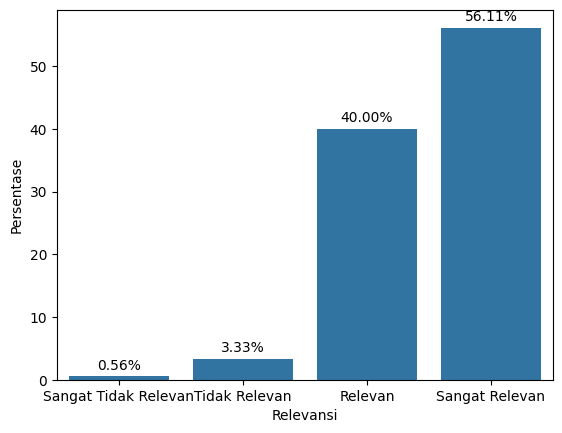

In [31]:
ax = sns.countplot(n_expert_df, x="relevancy", stat="percent")
ax.set_xticklabels(["Sangat Tidak Relevan", "Tidak Relevan", "Relevan", "Sangat Relevan"])
labels = [f'{v.get_height():.2f}%' if v.get_height() > 0 else '' for v in ax.containers[0]]
ax.bar_label(ax.containers[0], labels=labels, padding=3)
plt.xlabel("Relevansi")
plt.ylabel("Persentase")

## 2.B. Analysis of top events

In [48]:
query = """
MATCH (r:UniResource:Event)-[rs:SUPPORTS]->(i:Indicator)
MATCH (s:Student) 
WHERE s.nrp <> "c14220160"
MATCH (st:StudentTarget)
OPTIONAL MATCH (s)-[rh:HAS]->(i)
WITH r, i, s, st, COALESCE(rh.weight, 0) AS current_weight
WITH r, i, s, 
     CASE 
        WHEN st.target_score - current_weight <= 0 THEN 0 
        ELSE st.target_score - current_weight 
     END AS lack_score
WITH r, s, sum(lack_score) AS total_kebutuhan_mahasiswa_ini, count(i) AS total_indikator
RETURN r.title AS judul_kegiatan, 
       total_indikator AS jumlah_indikator_didukung, 
       avg(total_kebutuhan_mahasiswa_ini) AS skor_dampak_kebutuhan
ORDER BY skor_dampak_kebutuhan DESC
"""

df = gds.run_cypher(query)

In [49]:
rentang_warna = [df['skor_dampak_kebutuhan'].min(), df['skor_dampak_kebutuhan'].max()]

fig = px.bar(
    df.nlargest(10, 'skor_dampak_kebutuhan'), 
    x='jumlah_indikator_didukung', 
    y='judul_kegiatan', 
    color='skor_dampak_kebutuhan',
    range_color=rentang_warna,
    orientation='h', 
    title='10 Kegiatan Teratas Berdasarkan Kebutuhan Mahasiswa',
    labels={
        'skor_dampak_kebutuhan': 'Kebutuhan Mahasiswa',
        'judul_kegiatan': 'Judul Kegiatan',
        'jumlah_indikator_didukung': 'Jumlah Indikator Didukung'
    },
    color_continuous_scale='Blues',
    text_auto='.0f'
)

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    template='plotly_white',
    title_font=dict(size=20, color='#2C3E50', family='Arial'),
    font=dict(size=12, family='Arial'),
    height=700,
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.show()

## 2.C. Students' CSAT

In [13]:
student_precision_df = (
    (merged_students_df["satisfaction"] >= 3)
    .groupby([merged_students_df["email"]])
    .mean()
)

student_precision_all = student_precision_df.mean()
print(student_precision_df)
print(student_precision_all)

email
b12250025@john.petra.ac.id    0.75
c12250010@john.petra.ac.id    0.75
c14250004@john.petra.ac.id    1.00
c14250070@john.petra.ac.id    1.00
d11250051@john.petra.ac.id    0.75
d11250062@john.petra.ac.id    1.00
d12250086@john.petra.ac.id    1.00
g11250010@john.petra.ac.id    0.75
h15250025@john.petra.ac.id    0.50
Name: satisfaction, dtype: float64
0.8333333333333334


In [14]:
merged_students_df[merged_students_df['satisfaction'] <= 2]

,timestamp,email,question,satisfaction,commentary
3,6/4/2026 10:43:00,c12250010@john.petra.ac.id,Seberapa puas Anda dengan kecocokan rekomendas...,1,Untuk rekomendasi Digital Leadership Project k...
18,6/13/2026 19:37:27,d11250051@john.petra.ac.id,Seberapa puas Anda dengan kecocokan rekomendas...,1,Ada beberapa rekomendasi yang tidak cocok untu...
20,6/14/2026 13:07:03,b12250025@john.petra.ac.id,Seberapa puas Anda dengan kecocokan rekomendas...,1,"sebenarnya ini tergantung minat juga si, saya ..."
25,6/14/2026 9:23:38,h15250025@john.petra.ac.id,Seberapa puas Anda dengan kecocokan rekomendas...,2,Rekomendasi 2 dinilai partisipan sebagai tidak...
27,6/14/2026 9:23:38,h15250025@john.petra.ac.id,Seberapa puas Anda dengan kecocokan rekomendas...,2,Rekomendasi 2 dinilai partisipan sebagai tidak...
33,6/16/2026 11:31:52,g11250010@john.petra.ac.id,Seberapa puas Anda dengan kecocokan rekomendas...,2,sangat membantu


C:\Users\PC\AppData\Local\Temp\ipykernel_15632\2863139128.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Sangat Tidak Puas", "Tidak Puas", "Puas", "Sangat Puas"])


Text(0, 0.5, 'Persentase')

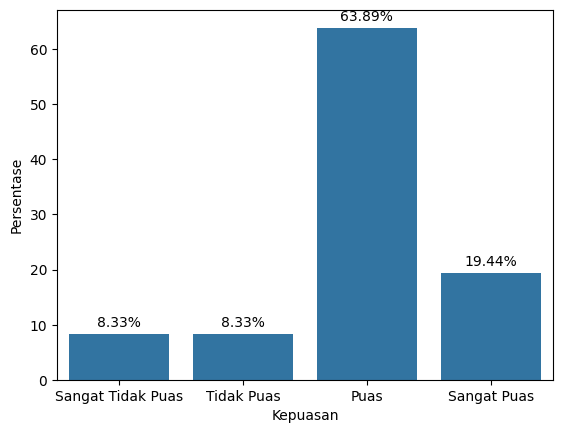

In [30]:
ax = sns.countplot(merged_students_df, x="satisfaction", stat="percent")
ax.set_xticklabels(["Sangat Tidak Puas", "Tidak Puas", "Puas", "Sangat Puas"])
labels = [f'{v.get_height():.2f}%' if v.get_height() > 0 else '' for v in ax.containers[0]]
ax.bar_label(ax.containers[0], labels=labels, padding=3)
plt.xlabel("Kepuasan")
plt.ylabel("Persentase")